In [1]:
import numpy as np
import matplotlib.pyplot as plt

import h5py
from scipy.fft import rfft, rfftfreq

In [2]:
from cycler import cycler
def load_plotting_setting():
    # colors=['#fe9f6d', '#de4968', '#8c2981', '#3b0f70', '#000004']
    # colors = plt.colormaps.get_cmap('tab20b').resampled(6).colors
    cmap = plt.colormaps.get_cmap('viridis')
    colors = cmap(np.linspace(0, 0.95, 5))

    default_cycler = cycler(color=colors)
    
    params = {'figure.figsize': (7, 5),
              'axes.prop_cycle': default_cycler,
              'axes.titlesize': 14,
              'legend.fontsize': 12,
              'axes.labelsize': 14,
              'axes.titlesize': 14,
              'xtick.labelsize': 12,
              'ytick.labelsize': 12,
              'xtick.direction': 'in',
              'ytick.direction': 'in',
              'xtick.top': True,
              'ytick.right': True
              }
    plt.rcParams.update(params)

load_plotting_setting()

(-5000.0, 5000.0)

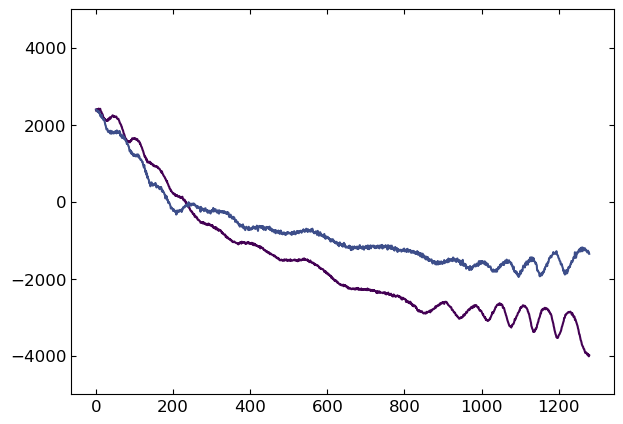

In [98]:
avg_a, avg_b = [], []
for i in range(1280):
    file_name = rf"E:\lorentz_force\sphere_20250708\20250807_2e-8mbar_highfreq\20250807_m350e_369khz_300vpp_withb_flipped_{i}.hdf5"
    f = h5py.File(file_name, 'r')

    avg_a.append(f['data'].attrs['channel_a_mean_mv'])
    avg_b.append(f['data'].attrs['channel_b_mean_mv'])

    f.close()

plt.plot(avg_a)
plt.plot(avg_b)
plt.ylim(-5000, 5000)

In [102]:
idx = 379

file_name = rf"E:\lorentz_force\sphere_20250708\20250807_2e-8mbar_highfreq\20250807_m350e_369khz_300vpp_withb_{idx}.hdf5"
f = h5py.File(file_name, 'r')

dd_0 = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv']/1000
gg_0 = f['data']['channel_g'][:] * f['data']['channel_g'].attrs['adc2mv']/1000

f.close()

In [138]:
idx = 2503

# file_name = rf"E:\lorentz_force\sphere_20250708\20250808_2e-8mbar_midfreq\20250808_m350e_276khz_350vpp_withb_flipped_{idx}.hdf5"
# file_name = rf"E:\lorentz_force\sphere_20250708\20250808_2e-8mbar_electric_calibration\20250808_m350e_93khz_7_5vpp_nob_0.hdf5"
file_name = rf"E:\lorentz_force\sphere_20250708\20250813_2e-8mbar_midfreq_fcancel\20250813_m350e_276khz_350vpp_withb_flipped_{idx}.hdf5"

f = h5py.File(file_name, 'r')

dd = f['data']['channel_d'][:] * f['data']['channel_d'].attrs['adc2mv']/1000
gg = f['data']['channel_g'][:] * f['data']['channel_g'].attrs['adc2mv']/1000

print(f['data'].attrs['pressure_mbar'])
print(f['data'].attrs['flip_info'])
print(f['data'].attrs['drive_info'])
print(f['data'].attrs['channel_a_mean_mv'])
print(f['data'].attrs['channel_b_mean_mv'])
print(f['data'].attrs['channel_c_mean_mv'])
print(np.mean(dd) * 1000)

f.close()

1.5e-08
12.02,0.134,1.611

2.23,10.50,23.415

-2750.9521197824492
-1436.765909915288
1.2455255572627861
17.140968942364296


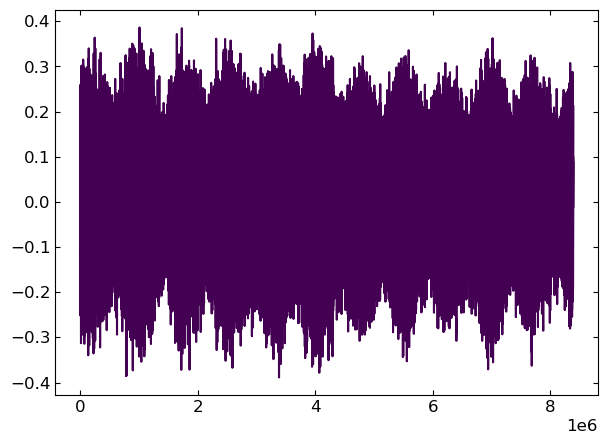

In [139]:
# plt.plot(gg)
plt.plot(dd)

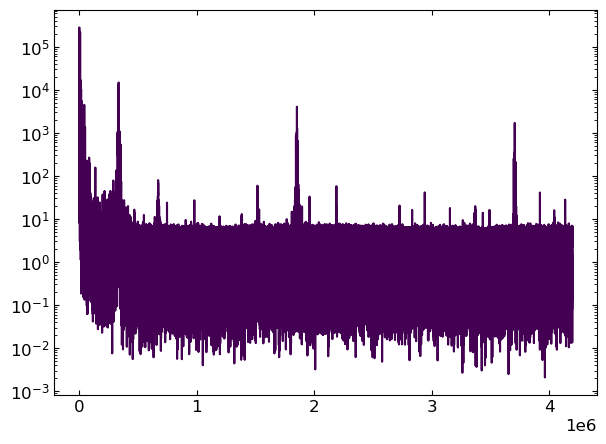

In [141]:
from scipy.fft import rfft

zzf = rfft(dd)
plt.plot(np.abs(zzf))
plt.yscale('log')